## Clustering Music Genres

This project groups music genres (or tracks) with similar sound characteristics using unsupervised learning (K-Means clustering). There are no predefined labels, so the goal is to find natural groups in the audio features and understand what makes each group different.


## Approach
1. Load the data and explore it (EDA)
2. Select the numeric audio features and check for missing values
3. Scale the features with `StandardScaler`, since K-Means is distance-based
4. Choose the number of clusters using the Elbow method and Silhouette score
5. Train the K-Means model and add the cluster labels to the data
6. Reduce the data to 2D with PCA and visualize the clusters
7. Profile each cluster (average audio features) and give it a meaningful name
8. Show at Streamplit.io

In [5]:
import pandas as pd
url='https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv'
df=pd.read_csv(url)
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## 1 - EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [7]:
df.isnull().sum()

,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


In [8]:
df = df.dropna()

In [9]:
df.shape

(32828, 23)

In [10]:
df.isnull().sum()

,0
track_id,0
track_name,0
track_artist,0
track_popularity,0
track_album_id,0
track_album_name,0
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


In [11]:
df.duplicated('track_id').sum()

np.int64(4476)

In [12]:
df = df.drop_duplicates('track_id')

In [14]:
df.shape

(28352, 23)

In [15]:
df.duplicated('track_id').sum()

np.int64(0)

In [16]:
df['playlist_genre'].value_counts()

,count
playlist_genre,
rap,5398
pop,5132
edm,4877
r&b,4504
rock,4305
latin,4136


In [18]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

In [19]:
df[audio_features].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,28352.0,0.653375,0.145791,0.000000,0.56100,0.670000,0.760000,0.983
energy,28352.0,0.698373,0.183508,0.000175,0.57900,0.722000,0.843000,1.000
loudness,28352.0,-6.817777,3.036433,-46.448000,-8.31025,-6.261000,-4.708750,1.275
speechiness,28352.0,0.107939,0.102547,0.000000,0.04100,0.062600,0.133000,0.918
acousticness,28352.0,0.177192,0.222814,0.000000,0.01430,0.079700,0.260000,0.994
instrumentalness,28352.0,0.091129,0.232562,0.000000,0.00000,0.000021,0.006573,0.994
liveness,28352.0,0.190955,0.155888,0.000000,0.09260,0.127000,0.249000,0.996
valence,28352.0,0.510386,0.234344,0.000000,0.32900,0.512000,0.695000,0.991
tempo,28352.0,120.958219,26.954502,0.000000,99.97200,121.993500,133.999000,239.440


In [20]:
df.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000
mean,39.335320,0.653375,0.698373,5.367417,-6.817777,0.565533,0.107939,0.177192,0.091129,0.190955,0.510386,120.958219,226574.631102
std,23.699443,0.145791,0.183508,3.613743,3.036433,0.495696,0.102547,0.222814,0.232562,0.155888,0.234344,26.954502,61081.363704
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,21.000000,0.561000,0.579000,2.000000,-8.310250,0.000000,0.041000,0.014300,0.000000,0.092600,0.329000,99.972000,187741.250000
50%,42.000000,0.670000,0.722000,6.000000,-6.261000,1.000000,0.062600,0.079700,0.000021,0.127000,0.512000,121.993500,216933.000000
75%,58.000000,0.760000,0.843000,9.000000,-4.708750,1.000000,0.133000,0.260000,0.006573,0.249000,0.695000,133.999000,254975.250000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [21]:
print((df['tempo'] == 0).sum(), (df['danceability'] == 0).sum())

1 1


In [22]:
df = df[(df['tempo'] > 0) & (df['danceability'] > 0)]

In [23]:
print((df['tempo'] == 0).sum(), (df['danceability'] == 0).sum())

0 0


In [24]:
df.shape

(28351, 23)

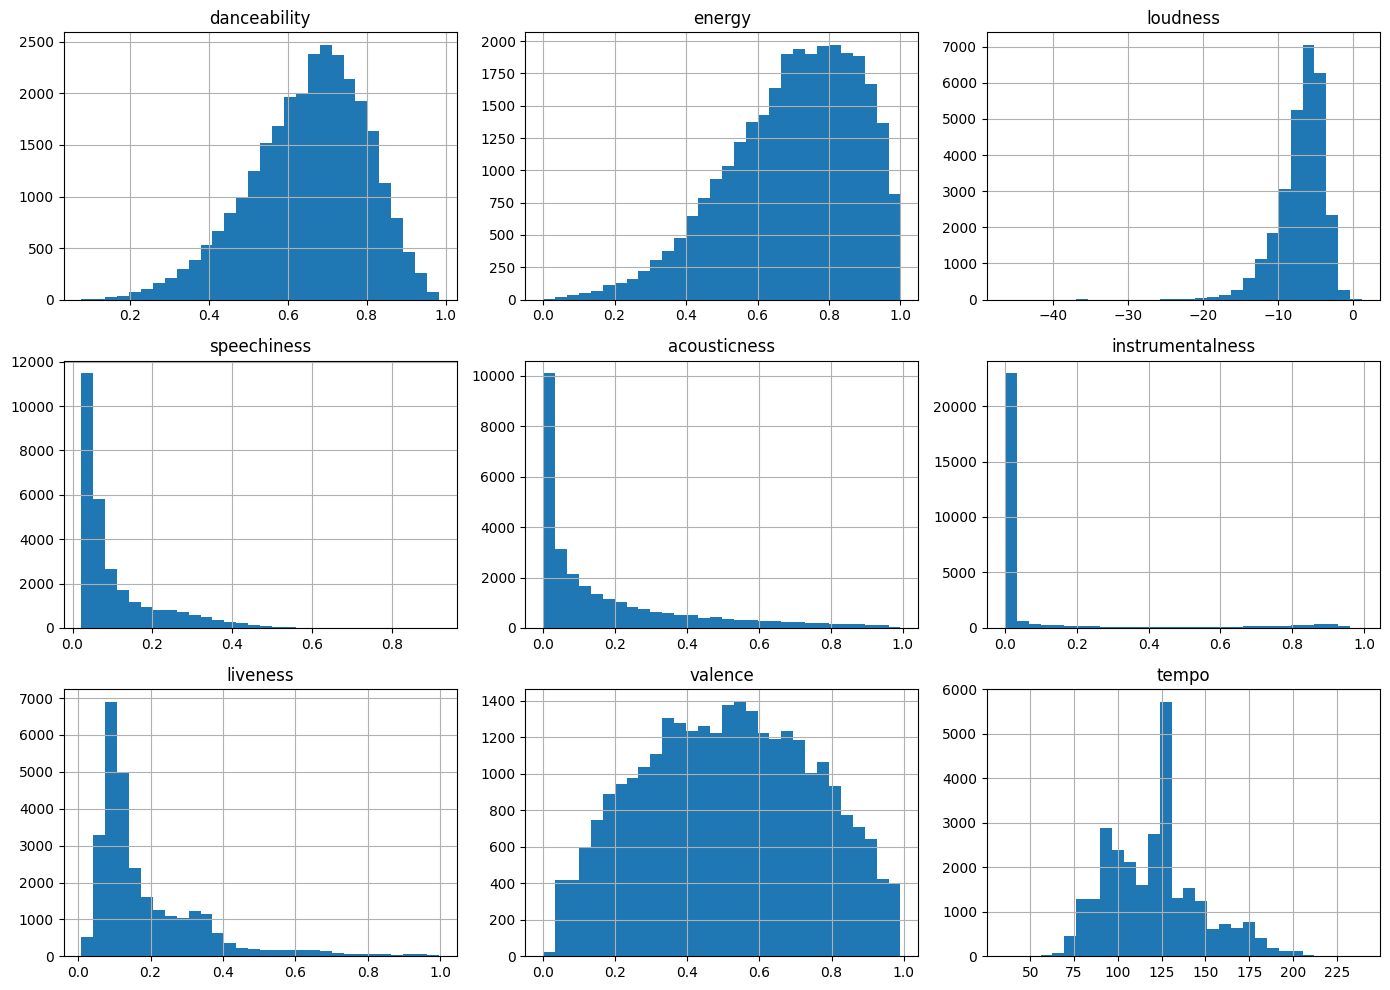

In [26]:
import matplotlib.pyplot as plt
df[audio_features].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

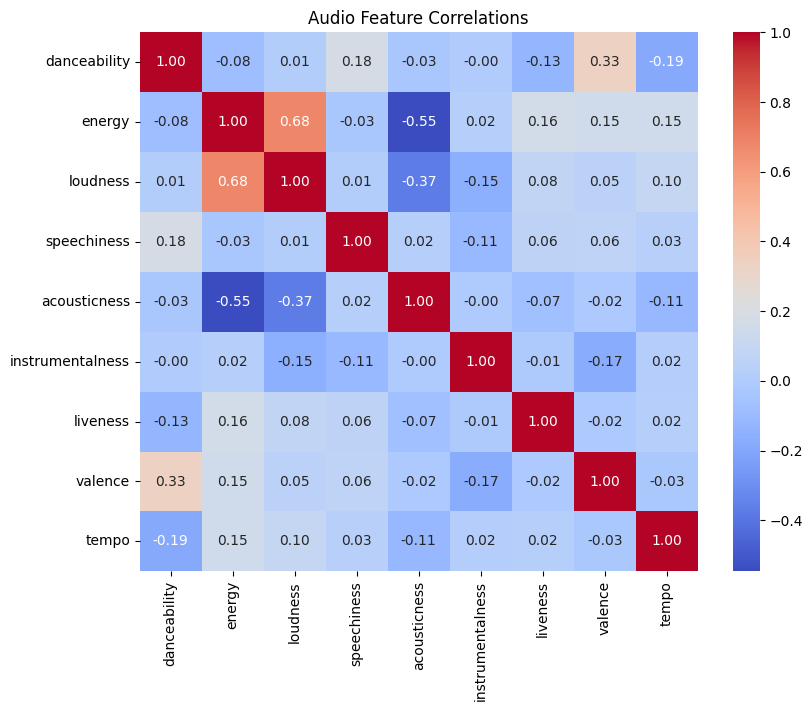

In [28]:
import seaborn as sns
plt.figure(figsize=(9, 7))
sns.heatmap(df[audio_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Audio Feature Correlations')
plt.show()

## 3- Scaling

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

x = df[audio_features]
x_scaled = StandardScaler().fit_transform(x)

## 5- Train the KMeans

In [31]:
model=KMeans(n_clusters=4, random_state=42, n_init=10)
model=model.fit(x_scaled)
tahmin=model.predict(x_scaled)
df['cluster']=tahmin
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,cluster
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,0
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,0
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,2
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,0


In [32]:
df['cluster'].value_counts().sort_index()

,count
cluster,
0,11931
1,2392
2,9351
3,4677


In [33]:
df.groupby('cluster')[audio_features].mean().round(2).T

cluster,0,1,2,3
danceability,0.75,0.66,0.55,0.61
energy,0.71,0.78,0.80,0.43
loudness,-6.51,-7.05,-5.31,-10.50
speechiness,0.14,0.07,0.09,0.09
acousticness,0.15,0.08,0.07,0.51
instrumentalness,0.01,0.75,0.02,0.09
liveness,0.16,0.19,0.24,0.16
valence,0.65,0.39,0.42,0.40
tempo,113.95,124.99,132.70,113.32


In [34]:
pd.crosstab(df['cluster'], df['playlist_genre'])

playlist_genre,edm,latin,pop,r&b,rap,rock
cluster,,,,,,
0,1016,2591,1955,2266,3220,883
1,1349,199,289,85,246,224
2,2341,829,2055,669,1111,2346
3,171,517,833,1484,821,851


<Axes: xlabel='cluster', ylabel='count'>

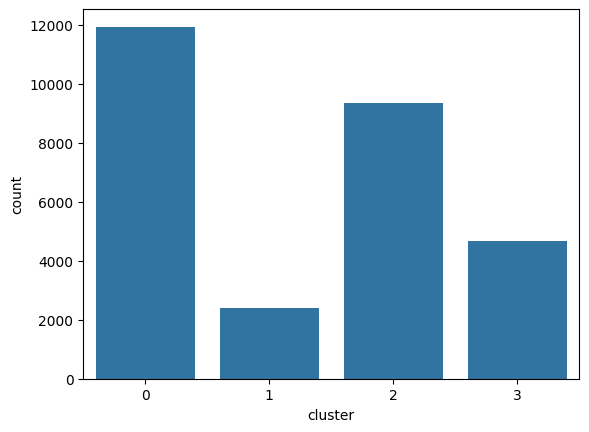

In [36]:
sns.countplot(x=df['cluster'])

## 4- Silhoutte Score

In [38]:
silhouette_score(x_scaled,tahmin)

np.float64(0.15299197601026476)

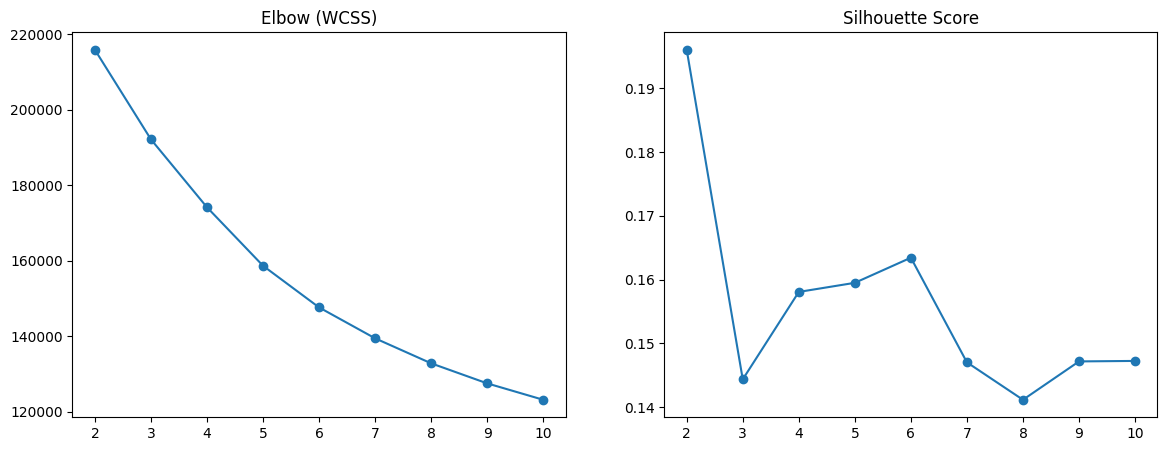

2 0.196
3 0.1443
4 0.1581
5 0.1595
6 0.1634
7 0.147
8 0.1411
9 0.1472
10 0.1472


In [39]:
wcss = []
ss = []
ks = range(2, 11)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x_scaled)
    wcss.append(model.inertia_)
    ss.append(silhouette_score(x_scaled, model.labels_, sample_size=5000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ks, wcss, marker='o'); ax[0].set_title('Elbow (WCSS)')
ax[1].plot(ks, ss, marker='o'); ax[1].set_title('Silhouette Score')
plt.show()

for k, s in zip(ks, ss):
    print(k, round(s, 4))

## 6- Visualize the Clusters

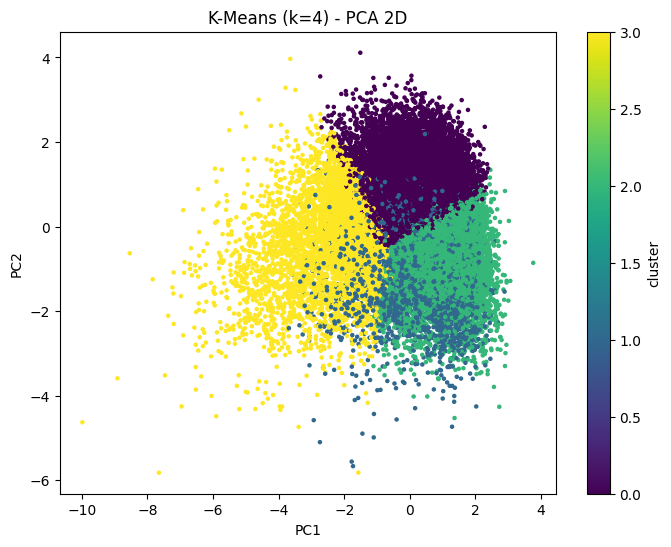

In [40]:
from sklearn.decomposition import PCA

x_pca = PCA(n_components=2, random_state=42).fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=df['cluster'], s=5, cmap='viridis')
plt.title('K-Means (k=4) - PCA 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(label='cluster')
plt.show()

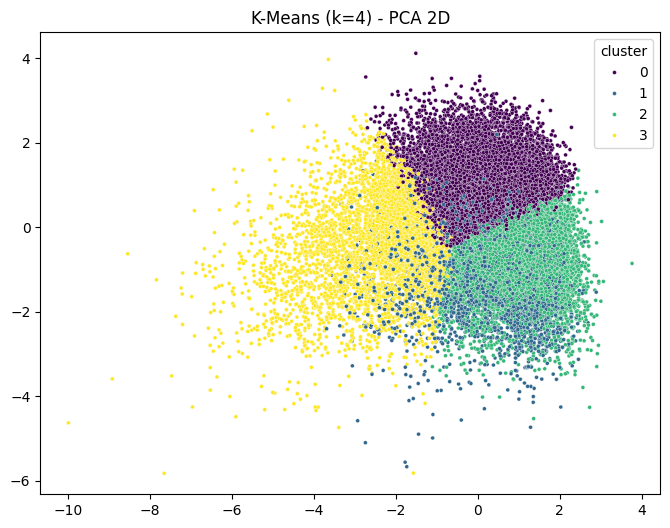

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=df['cluster'], palette='viridis', s=8)
plt.title('K-Means (k=4) - PCA 2D')
plt.show()

## 7 - Cluster Summary (K-Means, k = 4)

In [42]:
# Cluster - Songs -  Segment - Description
# 0         11,931 - Danceable & Vocal-Heavy - Very danceable, happy, and rich in vocals. Mostly rap, latin, and r&b.
# 1          2,392 - Instrumental / Electronic - Almost no vocals, high energy. Mostly EDM.
# 2          9,351 - Loud & Energetic - The loudest, most energetic, and fastest songs. Mostly rock and EDM.
# 3          4,677 - Calm & Acoustic - Quiet, low energy, and more acoustic. Mostly r&b, pop, and rock.

## 8 - Prepare for Streamlit

In [44]:
import pickle
from sklearn.pipeline import make_pipeline
pickle.dump(make_pipeline(StandardScaler(), KMeans(n_clusters=4, random_state=42, n_init=10)).fit(df[audio_features]), open("music_cluster_model.pkl", "wb"))